# 📦 Supply Chain & Inventory Optimization  
### Mini Project using SQL, Python & Data Visualization  

I know... supply chain data sounds a bit boring at first 😄  
But behind it lies one of the most critical parts of any business - how products move, how costs behave, and where delays happen.

In this project, we analyze supply chain operations using real-world style datasets to uncover inefficiencies and optimization opportunities.

We focus on three key areas:
- Customer and order behavior  
- Shipment performance and delays  
- Logistics efficiency and warehouse utilization  

---

## 🎯 What we will do in this project

- Analyze demand patterns across product categories  
- Identify delays and their root causes  
- Study cost vs value relationships in shipments  
- Evaluate warehouse utilization and logistics performance  
- Discover patterns that can improve inventory and operations  

---

## 🧠 Goal

The goal is simple:  
👉 Turn raw supply chain data into actionable insights  

So that businesses can:
- Reduce delays  
- Optimize inventory  
- Improve cost efficiency  
- Make better operational decisions  

---

Let’s dive into the data and see what the numbers tell us 📊

## 📥 Data Loading  

Time to bring the data into our system 😄  
Think of this step like opening all the files before starting work — without this, nothing moves!

Here we import the required libraries and load our cleaned datasets so we can start exploring and analyzing them.


In [24]:
# ============================================================
# Import Libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Load Cleaned Data
# ============================================================

customers = pd.read_csv('C:/Ishika/Supply-Chain-Inventory-Analysis/Data/Cleaned/customers_cleaned_v2.csv')
shipments = pd.read_csv('C:/Ishika/Supply-Chain-Inventory-Analysis/Data/Cleaned/shipments_cleaned_v2.csv')
logistics = pd.read_csv('C:/Ishika/Supply-Chain-Inventory-Analysis/Data/Cleaned/logistics_cleaned_v2.csv')

# Quick check
print("Customers:", customers.shape)
print("Shipments:", shipments.shape)
print("Logistics:", logistics.shape)

Customers: (750, 12)
Shipments: (728, 14)
Logistics: (100, 9)


## 🔍 Data Overview  

Let’s take a quick look at what we’re working with 👀  
Before jumping into analysis, it’s always good to understand the size and structure of the data — like checking ingredients before cooking 🍳

In [25]:
# Dataset shape
pd.DataFrame({
    "Dataset": ["Customers", "Shipments", "Logistics"],
    "Rows": [customers.shape[0], shipments.shape[0], logistics.shape[0]],
    "Columns": [customers.shape[1], shipments.shape[1], logistics.shape[1]]
})

,Dataset,Rows,Columns
0,Customers,750,12
1,Shipments,728,14
2,Logistics,100,9


## 🧹 Missing Values Check  

Let’s see if our data has any missing values 👀  
Because missing data is like missing puzzle pieces — analysis becomes confusing 🧩

In [26]:
shipments.isnull().sum().to_frame("Missing Values")

,Missing Values
shipment_id,0
type,0
date,0
product_category,0
origin,0
origin_country,0
destination,0
destination_country,0
value,0
freight_cost,0


## 📊 Summary Statistics  

Now let’s understand the numbers 📈  
This gives us a quick idea about averages, ranges, and overall data behavior.

In [27]:
shipments.describe()

,value,freight_cost,cost_ratio
count,728.000000,728.000000,728.000000
mean,139821.840659,6984.328297,0.048373
std,86590.613603,4340.281363,0.008815
min,3250.000000,2.200000,0.000652
25%,74500.000000,3725.000000,0.050000
50%,112000.000000,5600.000000,0.050000
75%,194250.000000,9712.500000,0.050000
max,415000.000000,20750.000000,0.050000


## 📦 Top Product Categories  

Let’s see which products are most in demand — because business runs where demand is 💰

In [28]:
shipments['product_category'].value_counts().head(10)

product_category
Electronics             194
Consumer Goods          194
Textiles                170
Industrial Equipment    170
Name: count, dtype: int64

## 📊 Demand Distribution  

Let’s visualize which products people love the most 😄

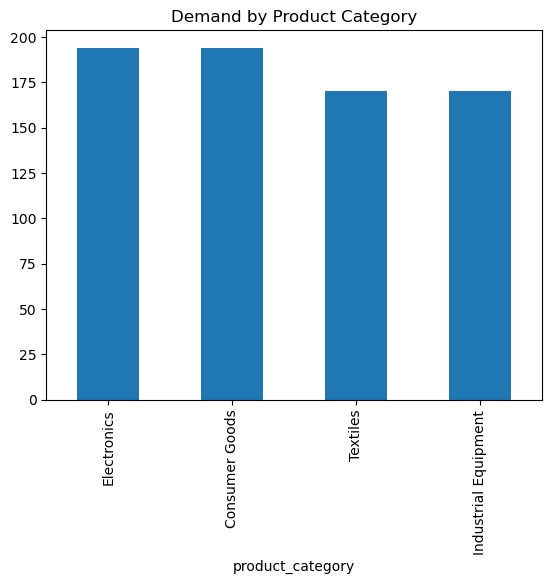

In [29]:
shipments['product_category'].value_counts().plot(kind='bar')
plt.title("Demand by Product Category")
plt.show()

## 🚚 Delivery Performance  

Are shipments reaching on time or causing headaches? 😅

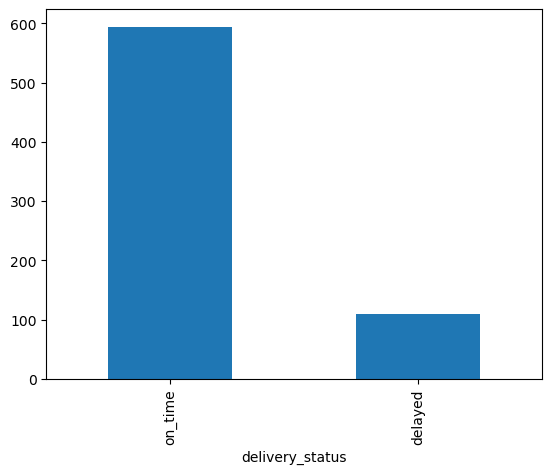

In [30]:
shipments['delivery_status'].value_counts().plot(kind='bar')
plt.show()

## ⏳ Delay Rate by Category  

Which products are causing delays? Let’s expose them 👀

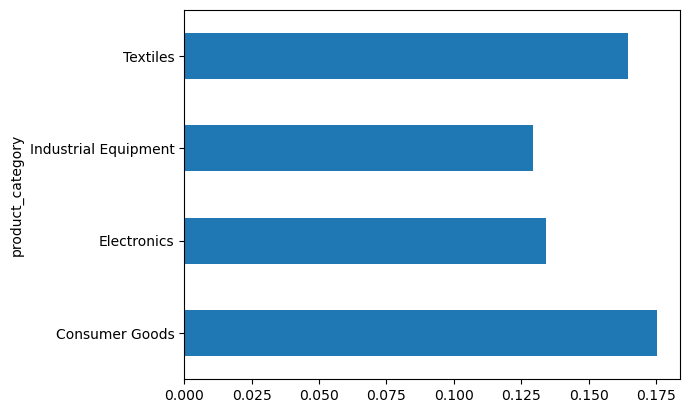

In [31]:
shipments.groupby('product_category')['is_delayed'].mean().plot(kind='barh')
plt.show()

## 💰 Value vs Cost  

Are we spending more to deliver high-value shipments?

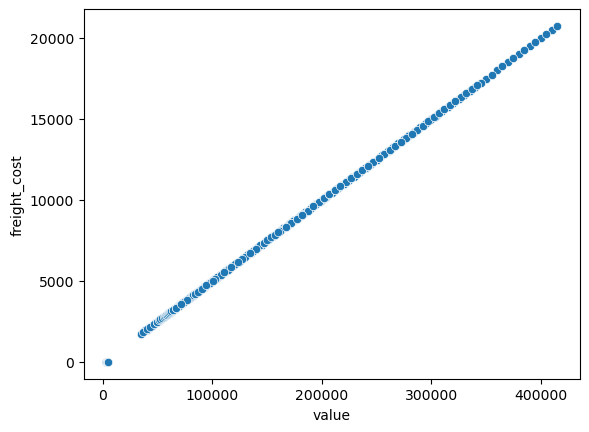

In [32]:
sns.scatterplot(x=shipments['value'], y=shipments['freight_cost'])
plt.show()

## 🔗 Correlation Heatmap  

Let’s see how variables are connected — who is influencing whom 😄

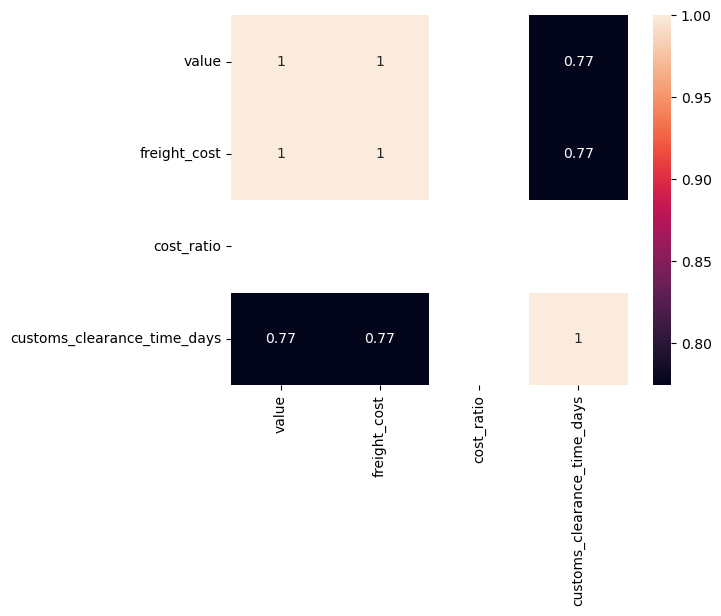

In [33]:
num = shipments[['value','freight_cost','cost_ratio','customs_clearance_time_days']].apply(pd.to_numeric, errors='coerce').dropna()
sns.heatmap(num.corr(), annot=True)
plt.show()

## 🏭 Warehouse Utilization  

Are warehouses chilling or overloaded? 😅

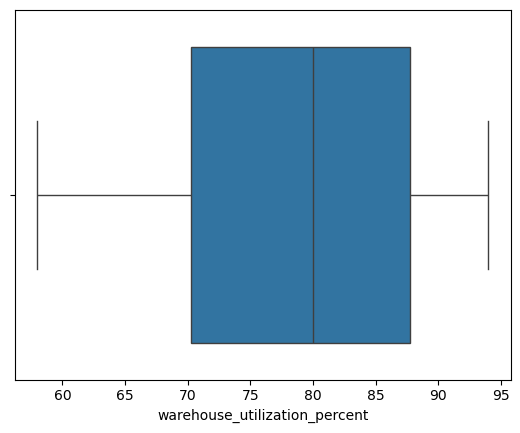

In [34]:
sns.boxplot(x=logistics['warehouse_utilization_percent'])
plt.show()

## ⛽ Fuel Price Impact  

Does expensive fuel slow things down?

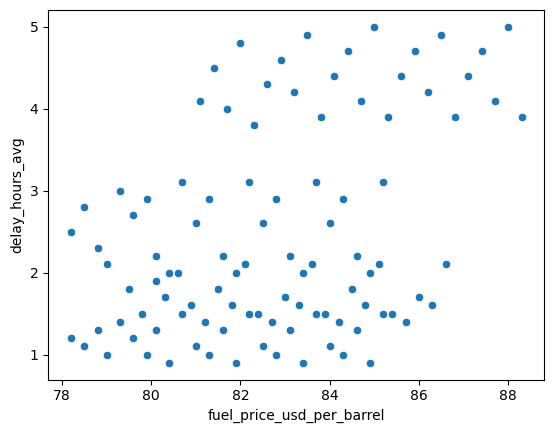

In [35]:
sns.scatterplot(x=logistics['fuel_price_usd_per_barrel'], y=logistics['delay_hours_avg'])
plt.show()

## 📅 Shipment Trend Over Time  

Are shipments increasing or decreasing?

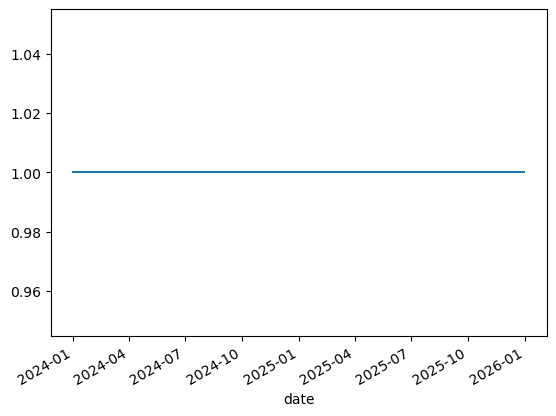

In [36]:
shipments['date'] = pd.to_datetime(shipments['date'])
shipments.groupby('date').size().plot()
plt.show()

## 🌍 Top Routes  

Which routes are used the most?

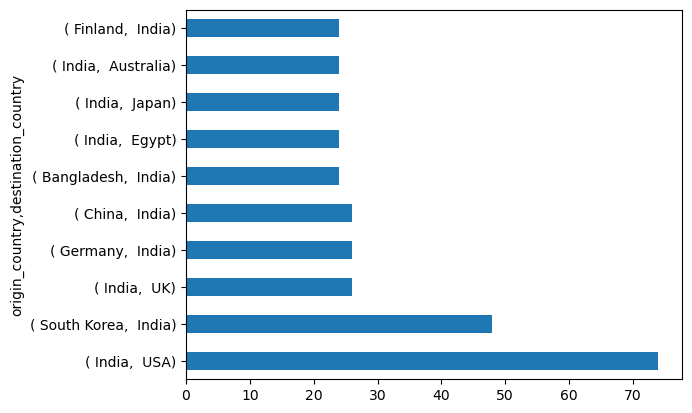

In [37]:
shipments.groupby(['origin_country','destination_country']).size().sort_values(ascending=False).head(10).plot(kind='barh')
plt.show()

## 💵 Customer Order Value  

How much are customers spending?

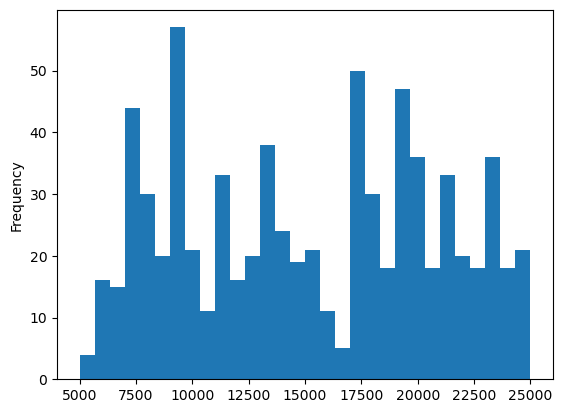

In [38]:
customers['order_value_usd'].plot(kind='hist', bins=30)
plt.show()

## 📊 Top Routes Table  

Let’s confirm our top routes in numbers.

In [39]:
shipments.groupby(['origin_country','destination_country']).size().sort_values(ascending=False).head(10)

origin_country  destination_country
India           USA                    74
South Korea     India                  48
India           UK                     26
Germany         India                  26
China           India                  26
Bangladesh      India                  24
India           Egypt                  24
                Japan                  24
                Australia              24
Finland         India                  24
dtype: int64